In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [ ]:
df = pd.read_csv('/Users/amanda.huang/Downloads/Call Center Model_2026-02-10-1245.csv')

Generating predictions...


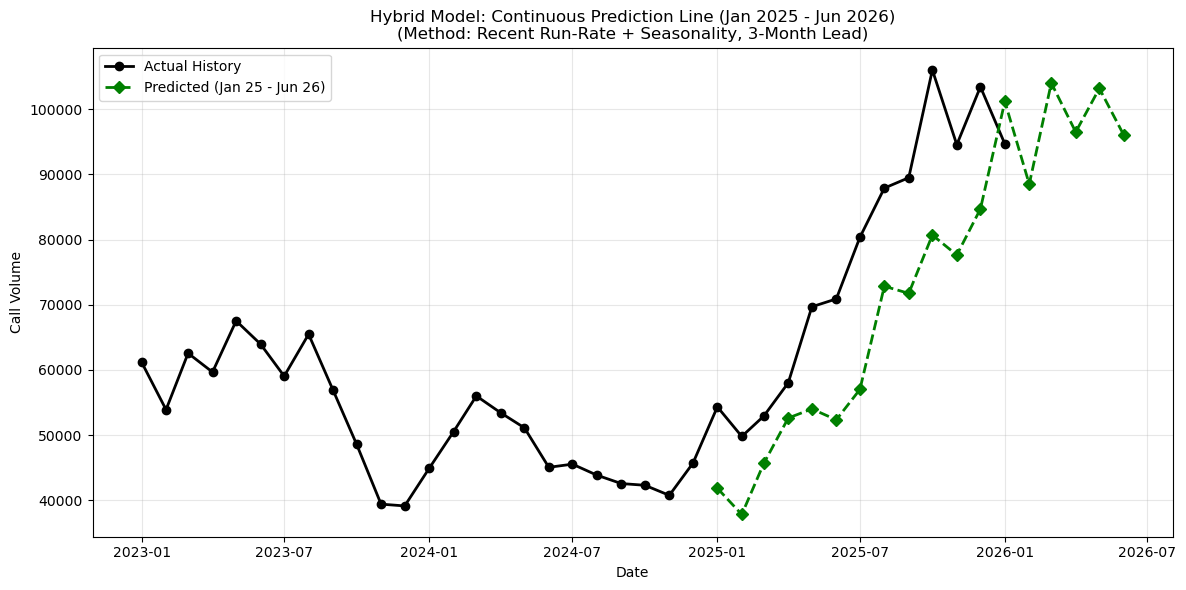

                Predicted    Actual
2025-01-01   41848.861866   54331.0
2025-02-01   37821.509036   49794.0
2025-03-01   45671.665733   52924.0
2025-04-01   52616.623307   58020.0
2025-05-01   54012.340762   69684.0
2025-06-01   52346.761215   70887.0
2025-07-01   57004.816421   80342.0
2025-08-01   72836.623225   87886.0
2025-09-01   71740.214330   89481.0
2025-10-01   80683.901496  106008.0
2025-11-01   77622.774403   94545.0
2025-12-01   84685.407174  103422.0
2026-01-01  101175.315126   94665.0
2026-02-01   88494.139143       NaN
2026-03-01  104005.244815       NaN
2026-04-01   96486.452689       NaN
2026-05-01  103181.302069       NaN
2026-06-01   96022.888761       NaN


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. LOAD DATA
# Replace with your actual file path
df = pd.read_csv('/Users/amanda.huang/Downloads/Call Center Model_2026-02-10-1245.csv')
df['MONTH'] = pd.to_datetime(df['MONTH'])

# Aggregate to Total Calls
total_calls = df.groupby('MONTH')['CALLS_COUNT'].sum()
total_calls.index.freq = 'MS'

# Add Jan 2026 Actual (since we know it now)
if pd.Timestamp('2026-01-01') not in total_calls.index:
    total_calls.loc[pd.Timestamp('2026-01-01')] = 94665

# 2. EXTRACT SEASONALITY (Full History)
decomp = seasonal_decompose(total_calls, model='multiplicative', extrapolate_trend='freq')
seasonal_indices = decomp.seasonal

def get_seasonal_factor(month):
    # Get average seasonal factor for a specific month
    return seasonal_indices[seasonal_indices.index.month == month].mean()

# 3. GENERATE PREDICTIONS (Jan 2025 to Jun 2026)
predictions = []
dates = pd.date_range(start='2025-01-01', end='2026-06-01', freq='MS')

print("Generating predictions...")

for target_date in dates:
    # LOGIC: 3-Month Lead Time
    # To predict Target, we use data available 3 months prior.
    cutoff_date = target_date - pd.DateOffset(months=3)
    
    # Get training data (everything known up to cutoff)
    # If cutoff is in the future (relative to actuals), we just take all available data
    train_data = total_calls[total_calls.index <= cutoff_date]
    if cutoff_date > total_calls.index.max():
        train_data = total_calls # Use everything we have
        
    if len(train_data) < 6:
        predictions.append(np.nan)
        continue
    
    # STEP A: Calculate Base Level (Run-Rate) from recent 6 months of KNOWN data
    recent_history = train_data.tail(6)
    
    try:
        # Simple Exp Smoothing (Alpha=0.8) -> Highly responsive
        model = SimpleExpSmoothing(
            recent_history, 
            initialization_method="estimated"
        ).fit(smoothing_level=0.8, optimized=False)
        
        # Forecast the Level
        # If we are predicting 3 months out, the level is just the last fitted value projected forward
        level_forecast = model.forecast(1).iloc[0]
        
        # STEP B: Apply Seasonality
        seasonal_factor = get_seasonal_factor(target_date.month)
        final_pred = level_forecast * seasonal_factor
        
        predictions.append(final_pred)
        
    except Exception as e:
        print(f"Error on {target_date}: {e}")
        predictions.append(np.nan)

# Create DataFrame
pred_series = pd.Series(predictions, index=dates)

# 4. PLOTTING
plt.figure(figsize=(12, 6))

# Plot Actual History (Black)
plt.plot(total_calls.index, total_calls, label='Actual History', color='black', marker='o', linewidth=2)

# Plot The Prediction Line (Green)
# This line shows:
#  - 2025: What the model would have predicted (Rolling Backtest)
#  - 2026: The future forecast
plt.plot(pred_series.index, pred_series, label='Predicted (Jan 25 - Jun 26)', color='green', linestyle='--', marker='D', linewidth=2)

plt.title('Hybrid Model: Continuous Prediction Line (Jan 2025 - Jun 2026)\n(Method: Recent Run-Rate + Seasonality, 3-Month Lead)')
plt.xlabel('Date')
plt.ylabel('Call Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('continuous_hybrid_forecast.png')
plt.show()

# 5. PRINT TABLE
output_df = pd.DataFrame({'Predicted': pred_series})
# Join with actuals where available
output_df = output_df.join(total_calls.rename("Actual"))
print(output_df)

--- Seasonal Multipliers (e.g., 1.05 = +5% traffic) ---
2026-01-01    0.941283
2026-02-01    0.908310
2026-03-01    1.006594
2026-04-01    0.990576
2026-05-01    1.059309
2026-06-01    0.985817
Freq: MS, Name: seasonal, dtype: float64

--- Final Hybrid Forecast (Jan - Jun 2026) ---
2026-01-01     95980.635639
2026-02-01     92618.459522
2026-03-01    102640.297547
2026-04-01    101006.994689
2026-05-01    108015.508288
2026-06-01    100521.712062
Freq: MS, dtype: float64


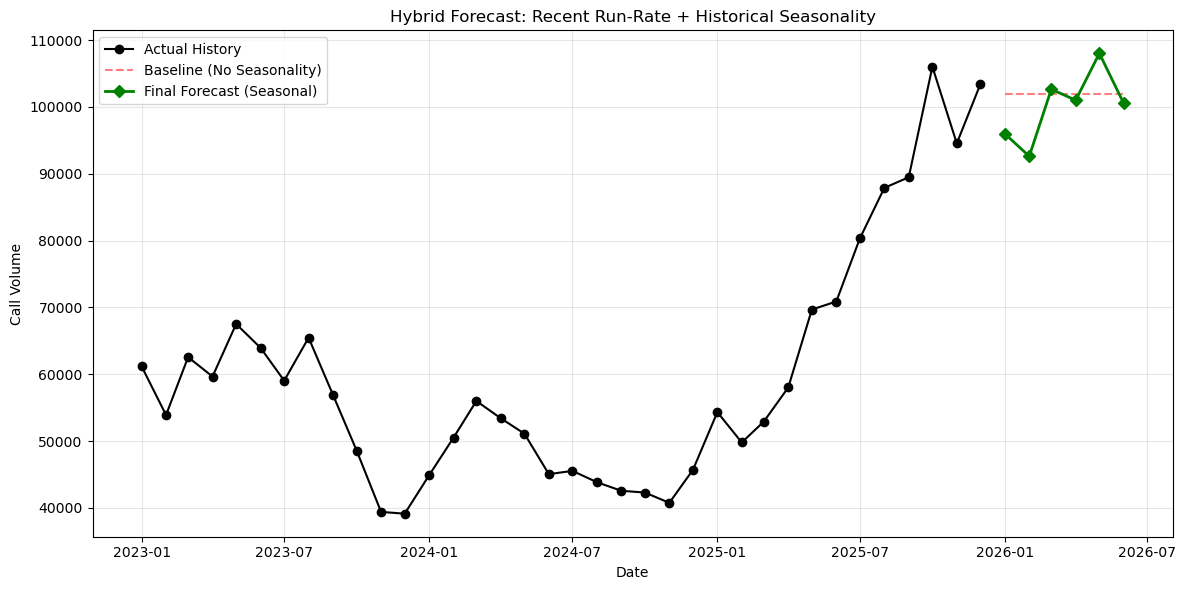

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. LOAD DATA
# Replace with your actual file path
df = pd.read_csv('/Users/amanda.huang/Downloads/Call Center Model_2026-02-10-1245.csv')
df['MONTH'] = pd.to_datetime(df['MONTH'])

# Aggregate to Total Calls (Best for capturing macro seasonality) fyufgy fdtufoli tdy3
total_calls = df.groupby('MONTH')['CALLS_COUNT'].sum()
total_calls.index.freq = 'MS' # Set frequency to Month Start

# 2. STEP A: EXTRACT SEASONALITY (From Full 3-Year History)
# We look at the full history to find the repeating monthly patterns
decomp = seasonal_decompose(total_calls, model='multiplicative', extrapolate_trend='freq')
seasonal_indices = decomp.seasonal

# Get the factors for the next 6 months (Jan - Jun)
# We take the factors from the last 12 months to ensure alignment
last_12_months = seasonal_indices.tail(12)
seasonal_factors = last_12_months[last_12_months.index.month.isin([1, 2, 3, 4, 5, 6])].sort_index()

# Re-index to future dates (2026) for easy multiplication
future_dates = pd.date_range(start='2026-01-01', periods=6, freq='MS')
seasonal_factors.index = future_dates

print("--- Seasonal Multipliers (e.g., 1.05 = +5% traffic) ---")
print(seasonal_factors)

# 3. STEP B: CALCULATE BASE LEVEL (From Recent 6 Months Only)
# We ignore the old 2024 data to avoid "polluting" the current run-rate 
recent_history = total_calls.tail(6)

# Simple Exponential Smoothing (Alpha=0.8) -> Highly responsive to recent
model_level = SimpleExpSmoothing(
    recent_history, 
    initialization_method="estimated"
).fit(smoothing_level=0.8, optimized=False)

flat_forecast = model_level.forecast(6)

# 4. STEP C: COMBINE (Level * Seasonality)
hybrid_forecast = flat_forecast * seasonal_factors

print("\n--- Final Hybrid Forecast (Jan - Jun 2026) ---")
print(hybrid_forecast)

# 5. PLOTTING
plt.figure(figsize=(12, 6))
# Plot History
plt.plot(total_calls.index, total_calls, label='Actual History', color='black', marker='o')
# Plot Flat Baseline
plt.plot(flat_forecast.index, flat_forecast, label='Baseline (No Seasonality)', linestyle='--', color='red', alpha=0.5)
# Plot Final Hybrid
plt.plot(hybrid_forecast.index, hybrid_forecast, label='Final Forecast (Seasonal)', linestyle='-', marker='D', color='green', linewidth=2)

plt.title('Hybrid Forecast: Recent Run-Rate + Historical Seasonality')
plt.xlabel('Date')
plt.ylabel('Call Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hybrid_forecast.png')
plt.show()

/var/folders/46/cr7dgrkj6wg5rb247mcvnzz40000gp/T/ipykernel_95742/1990115868.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quarterly_metrics = results.groupby('Quarter').apply(


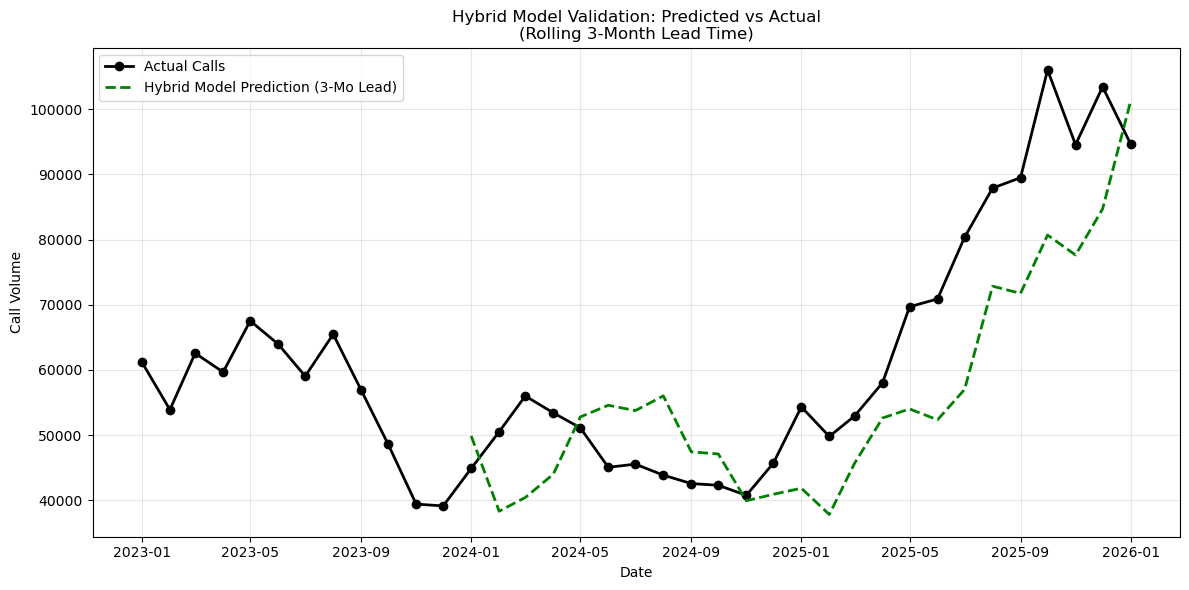


--- Quarterly Error Report (Predicted - Actual) / Actual ---
             MAPE      Bias
Quarter                    
2024Q1   0.210093 -0.136192
2024Q2   0.140063  0.022587
2024Q3   0.190646  0.190646
2024Q4   0.079410 -0.003821
2025Q1   0.202405 -0.202405
2025Q2   0.193191 -0.193191
2025Q3   0.219991 -0.219991
2025Q4   0.199680 -0.199680
2026Q1   0.068772  0.068772

Overall Bias: -8.63%
Overall MAPE: 17.50%


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. LOAD DATA
df['MONTH'] = pd.to_datetime(df['MONTH']) 
# Aggregate to Total Calls
total_calls = df.groupby('MONTH')['CALLS_COUNT'].sum()
total_calls.index.freq = 'MS'

# Add User's Jan 2026 Actual for the plot comparison  
total_calls.loc[pd.Timestamp('2026-01-01')] = 94665

# 2. CALCULATE SEASONALITY (Fixed from Full History) 
# We assume seasonality is a stable property of the business
decomp = seasonal_decompose(total_calls, model='multiplicative', extrapolate_trend='freq')
seasonal_indices = decomp.seasonal

def get_seasonal_factor(month):
    return seasonal_indices[seasonal_indices.index.month == month].mean()

# 3. ROLLING FORECAST LOOP (The Backtest)
predictions = []
actuals_aligned = []
dates = []

# Validate from Jan 2024 to Jan 2026
start_target = pd.Timestamp('2024-01-01')
end_target = pd.Timestamp('2026-01-01')
current_target = start_target

while current_target <= end_target:
    # 3-Month Lead Time: predicting 'current_target' using data from 3 months prior
    cutoff_date = current_target - pd.DateOffset(months=3)
    train_data = total_calls[total_calls.index <= cutoff_date]
    
    if len(train_data) < 6:
        current_target += pd.DateOffset(months=1)
        continue
        
    # LOGIC FROM CHUNK 1:
    # A. Level from recent 6 months 
    recent_history = train_data.tail(6)
    try:
        model = SimpleExpSmoothing(recent_history, initialization_method="estimated").fit(smoothing_level=0.8, optimized=False)
        level_forecast = model.forecast(1).iloc[0] # Flat level
        
        # B. Seasonality from historical factor
        seasonal_factor = get_seasonal_factor(current_target.month)
        
        # C. Combine
        pred = level_forecast * seasonal_factor
        
        predictions.append(pred)
        actuals_aligned.append(total_calls.loc[current_target])
        dates.append(current_target)
        
    except:
        pass
        
    current_target += pd.DateOffset(months=1)

# Create DataFrame
results = pd.DataFrame({
    'Actual': actuals_aligned,
    'Predicted': predictions
}, index=dates)

# 4. ERROR METRICS
results['Error'] = results['Predicted'] - results['Actual']
results['Pct_Error'] = results['Error'] / results['Actual']
results['Quarter'] = results.index.to_period('Q')

# Group by Quarter
quarterly_metrics = results.groupby('Quarter').apply(
    lambda x: pd.Series({
        'MAPE': (x['Error'].abs() / x['Actual']).mean(),
        'Bias': x['Pct_Error'].mean()
    })
)

# 5. PLOTTING
plt.figure(figsize=(12, 6))

# Plot Actuals
plt.plot(total_calls.index, total_calls, label='Actual Calls', color='black', linewidth=2, marker='o')

# Plot Model Predictions (3-Month Lead)
plt.plot(results.index, results['Predicted'], label='Hybrid Model Prediction (3-Mo Lead)', color='green', linestyle='--', linewidth=2)

plt.title('Hybrid Model Validation: Predicted vs Actual\n(Rolling 3-Month Lead Time)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Call Volume')
plt.tight_layout()
plt.show()

# 6. PRINT REPORT
print("\n--- Quarterly Error Report (Predicted - Actual) / Actual ---")
print(quarterly_metrics)
print(f"\nOverall Bias: {results['Pct_Error'].mean():.2%}")
print(f"Overall MAPE: {(results['Error'].abs() / results['Actual']).mean():.2%}")

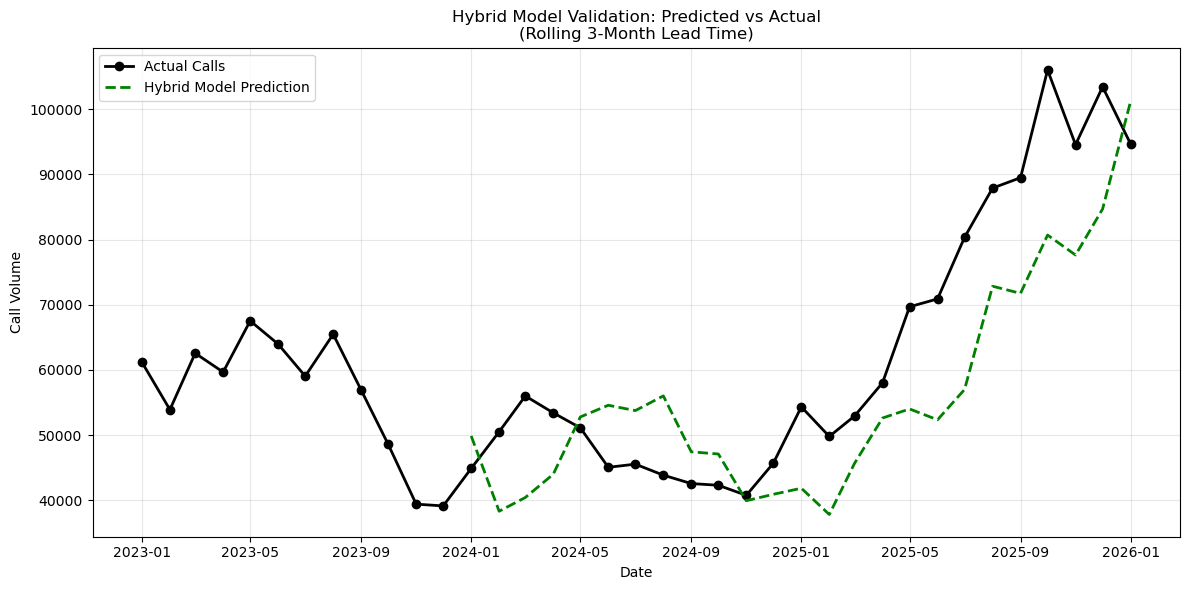


--- Quarterly Aggregated Error Report ---
         Actual      Predicted  Error_Pct
Quarter                                  
2024Q1   151401  128612.400472  -0.150518
2024Q2   149586  151365.290603   0.011895
2024Q3   131966  157205.963773   0.191261
2024Q4   128763  127954.585477  -0.006278
2025Q1   157049  125342.036635  -0.201892
2025Q2   198591  158975.725283  -0.199482
2025Q3   257709  201581.653977  -0.217794
2025Q4   303975  242992.083073  -0.200618
2026Q1    94665  101175.315126   0.068772

Formatted Error %:
Quarter
2024Q1    -15.05%
2024Q2      1.19%
2024Q3     19.13%
2024Q4     -0.63%
2025Q1    -20.19%
2025Q2    -19.95%
2025Q3    -21.78%
2025Q4    -20.06%
2026Q1      6.88%
Freq: Q-DEC, Name: Error_Pct, dtype: object


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. LOAD DATA
df['MONTH'] = pd.to_datetime(df['MONTH'])
total_calls = df.groupby('MONTH')['CALLS_COUNT'].sum()
total_calls.index.freq = 'MS'

# Add User's Jan 2026 Actual
total_calls.loc[pd.Timestamp('2026-01-01')] = 94665 

# 2. CALCULATE SEASONALITY (Full History - Chunk 1 Logic)
decomp = seasonal_decompose(total_calls, model='multiplicative', extrapolate_trend='freq')
seasonal_indices = decomp.seasonal

def get_seasonal_factor(month):
    return seasonal_indices[seasonal_indices.index.month == month].mean()

# 3. ROLLING FORECAST LOOP
predictions = []
actuals_aligned = []
dates = []

# Validate from Jan 2024 to Jan 2026
start_target = pd.Timestamp('2024-01-01')
end_target = pd.Timestamp('2026-01-01')
current_target = start_target

while current_target <= end_target:
    # 3-Month Lead Time
    cutoff_date = current_target - pd.DateOffset(months=3)
    train_data = total_calls[total_calls.index <= cutoff_date]
    
    if len(train_data) < 6:
        current_target += pd.DateOffset(months=1)
        continue
        
    # LOGIC: Level (6mo) * Seasonality
    recent_history = train_data.tail(6)
    try:
        model = SimpleExpSmoothing(recent_history, initialization_method="estimated").fit(smoothing_level=0.8, optimized=False)
        level_forecast = model.forecast(1).iloc[0]
        seasonal_factor = get_seasonal_factor(current_target.month)
        pred = level_forecast * seasonal_factor
        
        predictions.append(pred)
        actuals_aligned.append(total_calls.loc[current_target])
        dates.append(current_target)
        
    except:
        pass
        
    current_target += pd.DateOffset(months=1)

# Create DataFrame
results = pd.DataFrame({
    'Actual': actuals_aligned,
    'Predicted': predictions
}, index=dates)

# 4. CALCULATE AGGREGATED QUARTERLY ERROR
results['Quarter'] = results.index.to_period('Q')

# Group by Quarter and SUM first, then calculate error
quarterly_agg = results.groupby('Quarter').agg({
    'Actual': 'sum',
    'Predicted': 'sum'
})

quarterly_agg['Diff'] = quarterly_agg['Predicted'] - quarterly_agg['Actual']
quarterly_agg['Error_Pct'] = quarterly_agg['Diff'] / quarterly_agg['Actual']

# 5. PLOTTING
plt.figure(figsize=(12, 6))

# Plot Actuals
plt.plot(total_calls.index, total_calls, label='Actual Calls', color='black', linewidth=2, marker='o')

# Plot Predictions
plt.plot(results.index, results['Predicted'], label='Hybrid Model Prediction', color='green', linestyle='--', linewidth=2)

plt.title('Hybrid Model Validation: Predicted vs Actual\n(Rolling 3-Month Lead Time)')
plt.legend()
plt.grid(True, alpha=0.3)bn
plt.xlabel('Date')
plt.ylabel('Call Volume')
plt.tight_layout()
plt.show()
 
# 6. PRINT REPORT
print("\n--- Quarterly Aggregated Error Report ---")
print(quarterly_agg[['Actual', 'Predicted', 'Error_Pct']])

# Format for easier reading
print("\nFormatted Error %:")
print(quarterly_agg['Error_Pct'].apply(lambda x: f"{x:.2%}"))

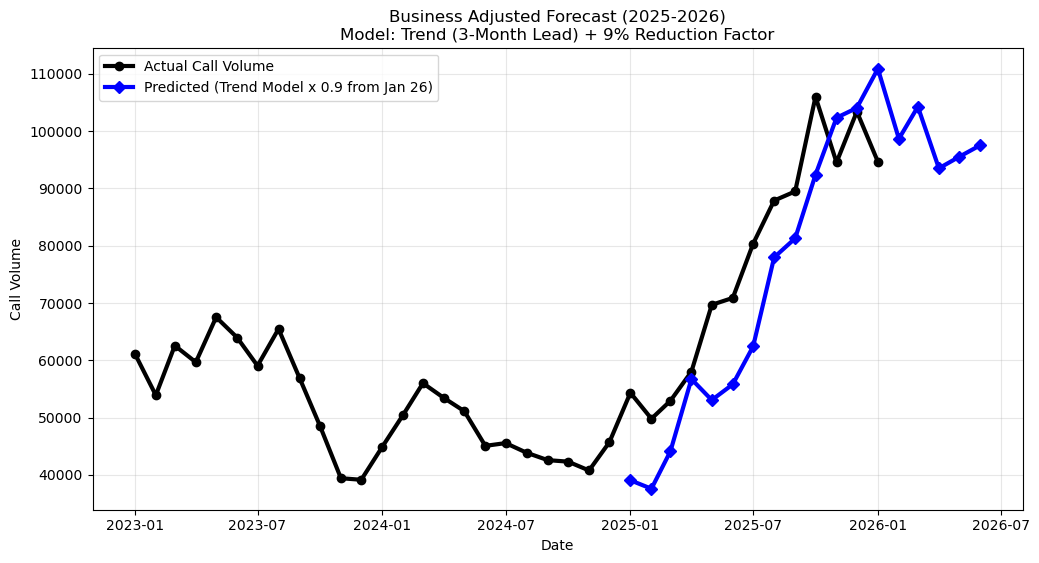

         Date  Adjusted_Forecast
12 2026-01-01      110903.295592
13 2026-02-01       98668.341508
14 2026-03-01      104275.200050
15 2026-04-01       93517.243750
16 2026-05-01       95529.997048
17 2026-06-01       97542.750346


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. LOAD DATA
df = pd.read_csv('/Users/amanda.huang/Downloads/Call Center Model_2026-02-10-1245.csv')
df['MONTH'] = pd.to_datetime(df['MONTH'])
total_calls = df.groupby('MONTH')['CALLS_COUNT'].sum()
total_calls.index.freq = 'MS'

# Add User's Jan 2026 Actual
total_calls.loc[pd.Timestamp('2026-01-01')] = 94665 

# ==========================================
# 2. YOUR ADJUSTMENT FACTOR (EDIT HERE)
# ==========================================
ADJUSTMENT_FACTOR = 0.90  # 90% of the model's trend prediction
ADJUSTMENT_START  = '2026-01-01' # When does this factor kick in?

# 3. ROLLING TREND FORECAST (Jan 2025 - Jun 2026)
predictions_adjusted = []
dates = pd.date_range(start='2025-01-01', end='2026-06-01', freq='MS')

for target_date in dates:
    # Logic: We stand at T-3 months to predict Month T
    cutoff_date = target_date - pd.DateOffset(months=3)
    train_data = total_calls[total_calls.index <= cutoff_date]
    
    if len(train_data) < 6:
        predictions_adjusted.append(np.nan)
        continue
        
    last_point = train_data.index.max()
    horizon = (target_date.year - last_point.year) * 12 + (target_date.month - last_point.month)
    
    # TREND MODEL (Holt's Linear)
    try:
        model = ExponentialSmoothing(
            train_data, 
            trend='add', 
            seasonal=None, 
            initialization_method="estimated"
        ).fit(smoothing_level=0.8, smoothing_trend=0.2, optimized=False)
        
        raw_val = model.forecast(horizon).iloc[-1]
    except:
        raw_val = np.nan
        
    # APPLY FACTOR (Only for future dates)
    if target_date >= pd.Timestamp(ADJUSTMENT_START):
        adj_val = raw_val * ADJUSTMENT_FACTOR
    else:
        adj_val = raw_val
        
    predictions_adjusted.append(adj_val)

# 4. PLOTTING
plt.figure(figsize=(12, 6))

# Plot Actuals (Stop where data stops)
actuals_to_plot = total_calls[total_calls.index <= '2026-01-01']
plt.plot(actuals_to_plot.index, actuals_to_plot, label='Actual Call Volume', color='black', linewidth=3, marker='o')

# Plot Adjusted Trend (Forecast Line)
label_text = f'Predicted (Trend Model x {ADJUSTMENT_FACTOR} from Jan 26)'
plt.plot(dates, predictions_adjusted, label=label_text, color='blue', linewidth=3, marker='D')

plt.title(f'Business Adjusted Forecast (2025-2026)\nModel: Trend (3-Month Lead) + {int((1-ADJUSTMENT_FACTOR)*100)}% Reduction Factor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Call Volume')
plt.show()

# Print Table
res_df = pd.DataFrame({'Date': dates, 'Adjusted_Forecast': predictions_adjusted})
print(res_df[res_df['Date'] >= '2026-01-01'])